Importando bibliotecas

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
import pandas as pd

# Mostrar todas as colunas
pd.set_option("display.max_columns", None)

# # Ajustar largura máxima de cada coluna (None = sem limite)
# pd.set_option("display.max_colwidth", None)

# # Ajustar largura total da tela (None = sem limite)
# pd.set_option("display.width", None)


Informações sobre a base de dados

In [3]:
obesity = pd.read_csv("Obesity.csv")
obesity.head()

,Gender,Age,Height,Weight,family_history,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,Obesity
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


FAVC: Consumo frequente de alimentos muito calóricos

FCVC: ) Frequência de consumo de vegetais nas refeições. Valores (escala 1–3):Valores (escala 1–3): 1 raramente, 2 às vezes, 3
sempre. Nota: no arquivo os valores aparecem com decimais (ruído); interprete arredondando para o inteiro mais próximo.

NCP: “Number of main meals”

CAEC: “Consumption of food between meals”

CH2O: Consumo diário de água. Valores (escala 1–3):Valores (escala 1–3): 1 < 1 L/dia, 2 1–2 L/dia, 3 > 2 L/dia.

SCC: “Calories consumption monitoring”

FAF: Frequência semanal de atividade física. Valores (escala 0–3):Valores (escala 0–3): 0 nenhuma, 1 ~1–2×/sem, 2 ~3–4×/sem, 3 5×/sem ou
mais.

TUE:  Tempo diário usando dispositivos eletrônicos. Valores (escala 0–2):Valores (escala 0–2): 0 ~0–2 h/dia, 1 ~3–5 h/dia, 2 > 5 h/dia.

CALC: “Consumption of alcohol”

MTRANS: “Transportation method”

Obesity: classificação do peso: O tipo 1 é considerado obesidade leve, o tipo 2 moderada e o tipo 3 grave ou mórbida

In [4]:
obesity.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Gender          2111 non-null   object 
 1   Age             2111 non-null   float64
 2   Height          2111 non-null   float64
 3   Weight          2111 non-null   float64
 4   family_history  2111 non-null   object 
 5   FAVC            2111 non-null   object 
 6   FCVC            2111 non-null   float64
 7   NCP             2111 non-null   float64
 8   CAEC            2111 non-null   object 
 9   SMOKE           2111 non-null   object 
 10  CH2O            2111 non-null   float64
 11  SCC             2111 non-null   object 
 12  FAF             2111 non-null   float64
 13  TUE             2111 non-null   float64
 14  CALC            2111 non-null   object 
 15  MTRANS          2111 non-null   object 
 16  Obesity         2111 non-null   object 
dtypes: float64(8), object(9)
memory u

In [5]:
obesity.describe().round(2)

,Age,Height,Weight,FCVC,NCP,CH2O,FAF,TUE
count,2111.00,2111.00,2111.00,2111.00,2111.00,2111.00,2111.00,2111.00
mean,24.31,1.70,86.59,2.42,2.69,2.01,1.01,0.66
std,6.35,0.09,26.19,0.53,0.78,0.61,0.85,0.61
min,14.00,1.45,39.00,1.00,1.00,1.00,0.00,0.00
25%,19.95,1.63,65.47,2.00,2.66,1.58,0.12,0.00
50%,22.78,1.70,83.00,2.39,3.00,2.00,1.00,0.63
75%,26.00,1.77,107.43,3.00,3.00,2.48,1.67,1.00
max,61.00,1.98,173.00,3.00,4.00,3.00,3.00,2.00


In [6]:
cols = ['CAEC', 'SMOKE', 'FAVC', 'family_history', 'Gender', 'CALC', 'SCC', 'MTRANS', 'Obesity']
for i in cols:
  print(f"{i} {obesity[i].unique()}")

CAEC ['Sometimes' 'Frequently' 'Always' 'no']
SMOKE ['no' 'yes']
FAVC ['no' 'yes']
family_history ['yes' 'no']
Gender ['Female' 'Male']
CALC ['no' 'Sometimes' 'Frequently' 'Always']
SCC ['no' 'yes']
MTRANS ['Public_Transportation' 'Walking' 'Automobile' 'Motorbike' 'Bike']
Obesity ['Normal_Weight' 'Overweight_Level_I' 'Overweight_Level_II'
 'Obesity_Type_I' 'Insufficient_Weight' 'Obesity_Type_II'
 'Obesity_Type_III']


Instalar sweet viz para gerar relatório para exploração da base de dados

In [7]:
# !pip install sweetviz

In [8]:
import sweetviz as sv
#Criar o relatório

# report = sv.analyze(obesity)

# Gerar html interativo

# report.show_html('obesity_report_html')

In [9]:
# Tratar valores decimais que deveriam ser inteiros

# Lista de colunas que devem ser inteiras (categorias discretas)
cols_to_round = [
    "Age",      # idade
    "FCVC",     # frequência de vegetais (1-3)
    "NCP",      # nº refeições principais (1-4)
    "CH2O",     # consumo de água (1-3)
    "FAF",      # atividade física (0-3)
    "TUE"       # tempo em dispositivos (0-2)
]

# Arredondar para o inteiro mais próximo

obesity[cols_to_round] = obesity[cols_to_round].round().astype(int)
obesity.head()

,Gender,Age,Height,Weight,family_history,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,Obesity
0,Female,21,1.62,64.0,yes,no,2,3,Sometimes,no,2,no,0,1,no,Public_Transportation,Normal_Weight
1,Female,21,1.52,56.0,yes,no,3,3,Sometimes,yes,3,yes,3,0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23,1.80,77.0,yes,no,2,3,Sometimes,no,2,no,2,1,Frequently,Public_Transportation,Normal_Weight
3,Male,27,1.80,87.0,no,no,3,3,Sometimes,no,2,no,2,0,Frequently,Walking,Overweight_Level_I
4,Male,22,1.78,89.8,no,no,2,1,Sometimes,no,2,no,0,0,Sometimes,Public_Transportation,Overweight_Level_II


In [10]:
obesity.isnull().sum()

,0
Gender,0
Age,0
Height,0
Weight,0
family_history,0
FAVC,0
FCVC,0
NCP,0
CAEC,0
SMOKE,0


<Axes: >

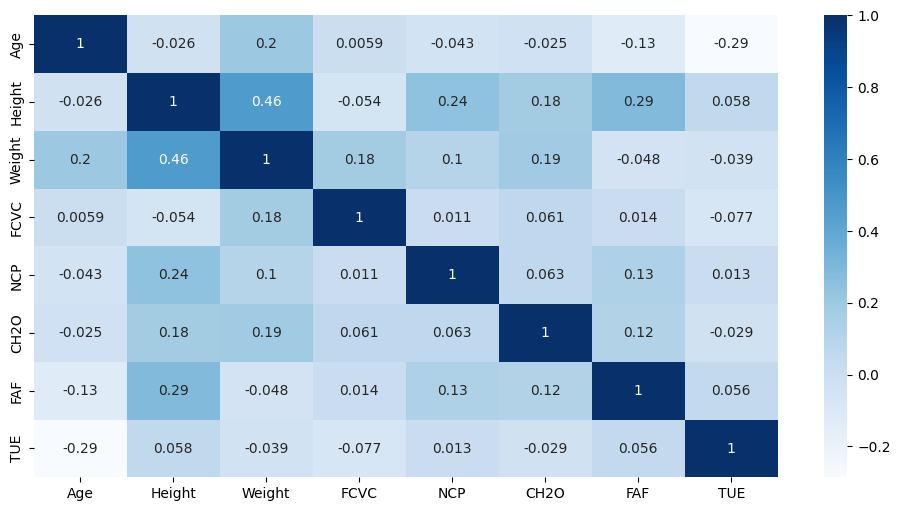

In [11]:
# Correlação de variáveis contínuas

num_cols = obesity.select_dtypes(include = ["int64", "float64"]).columns
corr = obesity[num_cols].corr()
plt.figure(figsize = (12,6))
sns.heatmap(corr, cmap = "Blues", annot = True)

In [12]:
obesity.duplicated().sum()

np.int64(27)

Criando algumas features

In [13]:
obesity['imc'] = obesity['Weight'] / obesity['Height']**2
obesity.head()

,Gender,Age,Height,Weight,family_history,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,Obesity,imc
0,Female,21,1.62,64.0,yes,no,2,3,Sometimes,no,2,no,0,1,no,Public_Transportation,Normal_Weight,24.386526
1,Female,21,1.52,56.0,yes,no,3,3,Sometimes,yes,3,yes,3,0,Sometimes,Public_Transportation,Normal_Weight,24.238227
2,Male,23,1.80,77.0,yes,no,2,3,Sometimes,no,2,no,2,1,Frequently,Public_Transportation,Normal_Weight,23.765432
3,Male,27,1.80,87.0,no,no,3,3,Sometimes,no,2,no,2,0,Frequently,Walking,Overweight_Level_I,26.851852
4,Male,22,1.78,89.8,no,no,2,1,Sometimes,no,2,no,0,0,Sometimes,Public_Transportation,Overweight_Level_II,28.342381


In [14]:
obesity["Age_Group"] = pd.cut(
    obesity["Age"],
    bins=[0,25,40,100],
    labels=["Young","Adult","Older"]
)
obesity.head()

,Gender,Age,Height,Weight,family_history,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,Obesity,imc,Age_Group
0,Female,21,1.62,64.0,yes,no,2,3,Sometimes,no,2,no,0,1,no,Public_Transportation,Normal_Weight,24.386526,Young
1,Female,21,1.52,56.0,yes,no,3,3,Sometimes,yes,3,yes,3,0,Sometimes,Public_Transportation,Normal_Weight,24.238227,Young
2,Male,23,1.80,77.0,yes,no,2,3,Sometimes,no,2,no,2,1,Frequently,Public_Transportation,Normal_Weight,23.765432,Young
3,Male,27,1.80,87.0,no,no,3,3,Sometimes,no,2,no,2,0,Frequently,Walking,Overweight_Level_I,26.851852,Adult
4,Male,22,1.78,89.8,no,no,2,1,Sometimes,no,2,no,0,0,Sometimes,Public_Transportation,Overweight_Level_II,28.342381,Young


In [15]:
obesity["Healthy_Score"] = (
    obesity["FCVC"] +
    obesity["FAF"] +
    obesity["CH2O"]
)
obesity.head()

,Gender,Age,Height,Weight,family_history,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,Obesity,imc,Age_Group,Healthy_Score
0,Female,21,1.62,64.0,yes,no,2,3,Sometimes,no,2,no,0,1,no,Public_Transportation,Normal_Weight,24.386526,Young,4
1,Female,21,1.52,56.0,yes,no,3,3,Sometimes,yes,3,yes,3,0,Sometimes,Public_Transportation,Normal_Weight,24.238227,Young,9
2,Male,23,1.80,77.0,yes,no,2,3,Sometimes,no,2,no,2,1,Frequently,Public_Transportation,Normal_Weight,23.765432,Young,6
3,Male,27,1.80,87.0,no,no,3,3,Sometimes,no,2,no,2,0,Frequently,Walking,Overweight_Level_I,26.851852,Adult,7
4,Male,22,1.78,89.8,no,no,2,1,Sometimes,no,2,no,0,0,Sometimes,Public_Transportation,Overweight_Level_II,28.342381,Young,4


In [16]:
# Índice de Sedentarismo
# TUE = technology usage time
# FAF = physical activity frequency

obesity["Sedentary_Index"] = obesity["TUE"] / (obesity["FAF"] + 1)
obesity.head()


,Gender,Age,Height,Weight,family_history,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,Obesity,imc,Age_Group,Healthy_Score,Sedentary_Index
0,Female,21,1.62,64.0,yes,no,2,3,Sometimes,no,2,no,0,1,no,Public_Transportation,Normal_Weight,24.386526,Young,4,1.000000
1,Female,21,1.52,56.0,yes,no,3,3,Sometimes,yes,3,yes,3,0,Sometimes,Public_Transportation,Normal_Weight,24.238227,Young,9,0.000000
2,Male,23,1.80,77.0,yes,no,2,3,Sometimes,no,2,no,2,1,Frequently,Public_Transportation,Normal_Weight,23.765432,Young,6,0.333333
3,Male,27,1.80,87.0,no,no,3,3,Sometimes,no,2,no,2,0,Frequently,Walking,Overweight_Level_I,26.851852,Adult,7,0.000000
4,Male,22,1.78,89.8,no,no,2,1,Sometimes,no,2,no,0,0,Sometimes,Public_Transportation,Overweight_Level_II,28.342381,Young,4,0.000000


In [17]:
# Fazer encoding manual, pois atividades tem pesos diferntes

activity_transport = {
    "Walking": 3,
    "Bike": 3,
    "Public_Transportation": 2,
    "Automobile": 1,
    'Motorbike': 1
}

obesity['MTRANS_Code'] = obesity['MTRANS'].map(activity_transport)
obesity.head(10)

,Gender,Age,Height,Weight,family_history,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,Obesity,imc,Age_Group,Healthy_Score,Sedentary_Index,MTRANS_Code
0,Female,21,1.62,64.0,yes,no,2,3,Sometimes,no,2,no,0,1,no,Public_Transportation,Normal_Weight,24.386526,Young,4,1.000000,2
1,Female,21,1.52,56.0,yes,no,3,3,Sometimes,yes,3,yes,3,0,Sometimes,Public_Transportation,Normal_Weight,24.238227,Young,9,0.000000,2
2,Male,23,1.80,77.0,yes,no,2,3,Sometimes,no,2,no,2,1,Frequently,Public_Transportation,Normal_Weight,23.765432,Young,6,0.333333,2
3,Male,27,1.80,87.0,no,no,3,3,Sometimes,no,2,no,2,0,Frequently,Walking,Overweight_Level_I,26.851852,Adult,7,0.000000,3
4,Male,22,1.78,89.8,no,no,2,1,Sometimes,no,2,no,0,0,Sometimes,Public_Transportation,Overweight_Level_II,28.342381,Young,4,0.000000,2
5,Male,29,1.62,53.0,no,yes,2,3,Sometimes,no,2,no,0,0,Sometimes,Automobile,Normal_Weight,20.195092,Adult,4,0.000000,1
6,Female,23,1.50,55.0,yes,yes,3,3,Sometimes,no,2,no,1,0,Sometimes,Motorbike,Normal_Weight,24.444444,Young,6,0.000000,1
7,Male,22,1.64,53.0,no,no,2,3,Sometimes,no,2,no,3,0,Sometimes,Public_Transportation,Normal_Weight,19.705532,Young,7,0.000000,2
8,Male,24,1.78,64.0,yes,yes,3,3,Sometimes,no,2,no,1,1,Frequently,Public_Transportation,Normal_Weight,20.199470,Young,6,0.500000,2
9,Male,22,1.72,68.0,yes,yes,2,3,Sometimes,no,2,no,1,1,no,Public_Transportation,Normal_Weight,22.985398,Young,5,0.500000,2


In [18]:
# ! pip install category_encoders

In [19]:
# Bynary Encoding

import category_encoders as ce

binary_cols = ['family_history','FAVC', 'SMOKE', 'SCC' ]
encoder = ce.BinaryEncoder(cols = binary_cols)
obesity_encoded = encoder.fit_transform(obesity)
obesity_encoded

,Gender,Age,Height,Weight,family_history_0,family_history_1,FAVC_0,FAVC_1,FCVC,NCP,CAEC,SMOKE_0,SMOKE_1,CH2O,SCC_0,SCC_1,FAF,TUE,CALC,MTRANS,Obesity,imc,Age_Group,Healthy_Score,Sedentary_Index,MTRANS_Code
0,Female,21,1.620000,64.000000,0,1,0,1,2,3,Sometimes,0,1,2,0,1,0,1,no,Public_Transportation,Normal_Weight,24.386526,Young,4,1.000000,2
1,Female,21,1.520000,56.000000,0,1,0,1,3,3,Sometimes,1,0,3,1,0,3,0,Sometimes,Public_Transportation,Normal_Weight,24.238227,Young,9,0.000000,2
2,Male,23,1.800000,77.000000,0,1,0,1,2,3,Sometimes,0,1,2,0,1,2,1,Frequently,Public_Transportation,Normal_Weight,23.765432,Young,6,0.333333,2
3,Male,27,1.800000,87.000000,1,0,0,1,3,3,Sometimes,0,1,2,0,1,2,0,Frequently,Walking,Overweight_Level_I,26.851852,Adult,7,0.000000,3
4,Male,22,1.780000,89.800000,1,0,0,1,2,1,Sometimes,0,1,2,0,1,0,0,Sometimes,Public_Transportation,Overweight_Level_II,28.342381,Young,4,0.000000,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2106,Female,21,1.710730,131.408528,0,1,1,0,3,3,Sometimes,0,1,2,0,1,2,1,Sometimes,Public_Transportation,Obesity_Type_III,44.901475,Young,7,0.333333,2
2107,Female,22,1.748584,133.742943,0,1,1,0,3,3,Sometimes,0,1,2,0,1,1,1,Sometimes,Public_Transportation,Obesity_Type_III,43.741923,Young,6,0.500000,2
2108,Female,23,1.752206,133.689352,0,1,1,0,3,3,Sometimes,0,1,2,0,1,1,1,Sometimes,Public_Transportation,Obesity_Type_III,43.543817,Young,6,0.500000,2
2109,Female,24,1.739450,133.346641,0,1,1,0,3,3,Sometimes,0,1,3,0,1,1,1,Sometimes,Public_Transportation,Obesity_Type_III,44.071535,Young,7,0.500000,2


In [20]:
obesity['gender_binary'] = obesity['Gender'].map({'Male': 0, 'Female': 1})
obesity.head()

,Gender,Age,Height,Weight,family_history,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,Obesity,imc,Age_Group,Healthy_Score,Sedentary_Index,MTRANS_Code,gender_binary
0,Female,21,1.62,64.0,yes,no,2,3,Sometimes,no,2,no,0,1,no,Public_Transportation,Normal_Weight,24.386526,Young,4,1.000000,2,1
1,Female,21,1.52,56.0,yes,no,3,3,Sometimes,yes,3,yes,3,0,Sometimes,Public_Transportation,Normal_Weight,24.238227,Young,9,0.000000,2,1
2,Male,23,1.80,77.0,yes,no,2,3,Sometimes,no,2,no,2,1,Frequently,Public_Transportation,Normal_Weight,23.765432,Young,6,0.333333,2,0
3,Male,27,1.80,87.0,no,no,3,3,Sometimes,no,2,no,2,0,Frequently,Walking,Overweight_Level_I,26.851852,Adult,7,0.000000,3,0
4,Male,22,1.78,89.8,no,no,2,1,Sometimes,no,2,no,0,0,Sometimes,Public_Transportation,Overweight_Level_II,28.342381,Young,4,0.000000,2,0


In [21]:
caec_freq = {
    "no": 0,
    "Sometimes": 1,
    "Frequently": 2,
    "Always": 3
}

obesity['caec_code'] = obesity['CAEC'].map(caec_freq)
obesity.head()


,Gender,Age,Height,Weight,family_history,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,Obesity,imc,Age_Group,Healthy_Score,Sedentary_Index,MTRANS_Code,gender_binary,caec_code
0,Female,21,1.62,64.0,yes,no,2,3,Sometimes,no,2,no,0,1,no,Public_Transportation,Normal_Weight,24.386526,Young,4,1.000000,2,1,1
1,Female,21,1.52,56.0,yes,no,3,3,Sometimes,yes,3,yes,3,0,Sometimes,Public_Transportation,Normal_Weight,24.238227,Young,9,0.000000,2,1,1
2,Male,23,1.80,77.0,yes,no,2,3,Sometimes,no,2,no,2,1,Frequently,Public_Transportation,Normal_Weight,23.765432,Young,6,0.333333,2,0,1
3,Male,27,1.80,87.0,no,no,3,3,Sometimes,no,2,no,2,0,Frequently,Walking,Overweight_Level_I,26.851852,Adult,7,0.000000,3,0,1
4,Male,22,1.78,89.8,no,no,2,1,Sometimes,no,2,no,0,0,Sometimes,Public_Transportation,Overweight_Level_II,28.342381,Young,4,0.000000,2,0,1


In [22]:
calc_freq = {
    "no": 0,
    "Sometimes": 1,
    "Frequently": 2,
    "Always": 3
}

obesity['calc_code'] = obesity['CALC'].map(calc_freq)
obesity.head()

,Gender,Age,Height,Weight,family_history,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,Obesity,imc,Age_Group,Healthy_Score,Sedentary_Index,MTRANS_Code,gender_binary,caec_code,calc_code
0,Female,21,1.62,64.0,yes,no,2,3,Sometimes,no,2,no,0,1,no,Public_Transportation,Normal_Weight,24.386526,Young,4,1.000000,2,1,1,0
1,Female,21,1.52,56.0,yes,no,3,3,Sometimes,yes,3,yes,3,0,Sometimes,Public_Transportation,Normal_Weight,24.238227,Young,9,0.000000,2,1,1,1
2,Male,23,1.80,77.0,yes,no,2,3,Sometimes,no,2,no,2,1,Frequently,Public_Transportation,Normal_Weight,23.765432,Young,6,0.333333,2,0,1,2
3,Male,27,1.80,87.0,no,no,3,3,Sometimes,no,2,no,2,0,Frequently,Walking,Overweight_Level_I,26.851852,Adult,7,0.000000,3,0,1,2
4,Male,22,1.78,89.8,no,no,2,1,Sometimes,no,2,no,0,0,Sometimes,Public_Transportation,Overweight_Level_II,28.342381,Young,4,0.000000,2,0,1,1


<Axes: ylabel='Weight'>

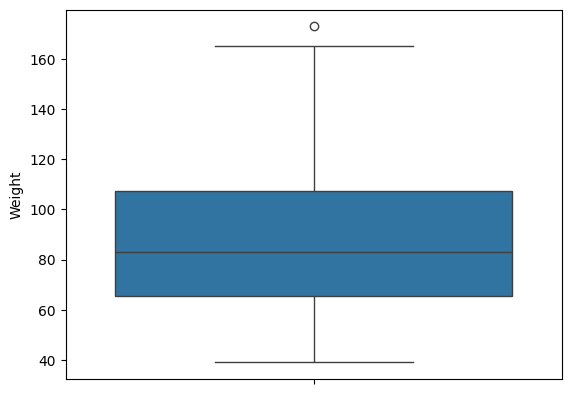

In [28]:
# Outliers

sns.boxplot(obesity['Weight'])

<Axes: ylabel='Height'>

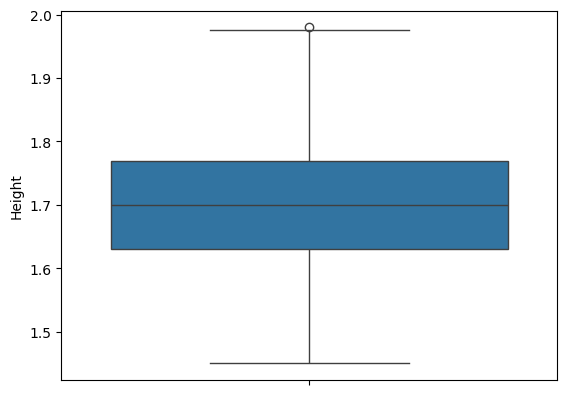

In [29]:
sns.boxplot(obesity['Height'])

In [24]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [31]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Definir colunas
num_cols = ["Height", "Weight", "Age", "imc", "Healthy_Score", "Sedentary_Index", "FCVC", "NCP", "CH2O", "FAF", "TUE"]
cat_cols = ["Gender", "family_history", "FAVC", "CAEC", "SMOKE", "SCC", "CALC", "MTRANS"]

# Transformer
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ]
)

   Gender  Age  Height  Weight family_history FAVC  FCVC  NCP       CAEC  \
0  Female   21    1.62    64.0            yes   no     2    3  Sometimes   
1  Female   21    1.52    56.0            yes   no     3    3  Sometimes   
2    Male   23    1.80    77.0            yes   no     2    3  Sometimes   
3    Male   27    1.80    87.0             no   no     3    3  Sometimes   
4    Male   22    1.78    89.8             no   no     2    1  Sometimes   

  SMOKE  CH2O  SCC  FAF  TUE        CALC                 MTRANS  \
0    no     2   no    0    1          no  Public_Transportation   
1   yes     3  yes    3    0   Sometimes  Public_Transportation   
2    no     2   no    2    1  Frequently  Public_Transportation   
3    no     2   no    2    0  Frequently                Walking   
4    no     2   no    0    0   Sometimes  Public_Transportation   

               Obesity        imc Age_Group  Healthy_Score  Sedentary_Index  \
0        Normal_Weight  24.386526     Young              4   

Feature Selection